# ITGAP: Data Preparation

Documents how the training datasets in `data/` were generated from the 10x Genomics benchmark:

1. **Inspect** the raw AnnData — cell counts, peptide distribution, donor breakdown
2. **Generate negative samples** — synthetic TCR-peptide pairs via two-stage per-instance sampling
3. **Create train/val/test splits** — three strategies, 5 runs each

Pre-generated outputs are included in `data/` so the prediction notebooks run without this notebook.  
Run this notebook to reproduce those files from scratch or adapt the pipeline to a new dataset.

**Required:** `data/merge_gex_all_donors_all_peptides_meta.h5ad`  
Download from 10x Genomics (see README) and place in `data/`.  
The h5ad file is not in the repository due to file size (~200 MB).

## 1. Configuration

In [1]:
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import GroupShuffleSplit, train_test_split
import warnings
warnings.filterwarnings('ignore')

from negative_sampling_tool import NegativeSamplingTool

# --- USER CONFIG ---
H5AD_PATH       = "data/merge_gex_all_donors_all_peptides_meta.h5ad"
NEGATIVE_RATIOS = [3.0, 5.0]   # generate datasets for both ratios
RANDOM_SEED     = 42
N_RUNS          = 5            # independent train/val/test splits per ratio

## 2. Dataset Overview

In [2]:
adata = ad.read_h5ad(H5AD_PATH)
print(f"Shape: {adata.shape}  ({adata.shape[0]:,} cells x {adata.shape[1]:,} genes)")
print(f"\nObs columns: {list(adata.obs.columns)}")

Shape: (145479, 5000)  (145,479 cells x 5,000 genes)

Obs columns: ['v_gene_TRA', 'v_gene_TRB', 'd_gene_TRA', 'd_gene_TRB', 'j_gene_TRA', 'j_gene_TRB', 'c_gene_TRA', 'c_gene_TRB', 'cdr3_TRA', 'cdr3_TRB', 'cdr3_nt_TRA', 'cdr3_nt_TRB', 'umis_TRA', 'umis_TRB', 'donor', 'cell_clono_cdr3_aa', 'cell_clono_cdr3_nt', 'CD3', 'CD19', 'CD45RA', 'CD4', 'CD8a', 'CD14', 'CD45RO', 'CD279_PD-1', 'IgG1', 'IgG2a', 'IgG2b', 'CD127', 'CD197_CCR7', 'HLA-DR', 'A0101_VTEHDTLLY_IE-1_CMV', 'A0201_KTWGQYWQV_gp100_Cancer', 'A0201_ELAGIGILTV_MART-1_Cancer', 'A0201_CLLWSFQTSA_Tyrosinase_Cancer', 'A0201_IMDQVPFSV_gp100_Cancer', 'A0201_SLLMWITQV_NY-ESO-1_Cancer', 'A0201_KVAELVHFL_MAGE-A3_Cancer', 'A0201_KVLEYVIKV_MAGE-A1_Cancer', 'A0201_CLLGTYTQDV_Kanamycin-B-dioxygenase', 'A0201_LLDFVRFMGV_EBNA-3B_EBV', 'A0201_LLMGTLGIVC_HPV-16E7_82-91', 'A0201_CLGGLLTMV_LMP-2A_EBV', 'A0201_YLLEMLWRL_LMP1_EBV', 'A0201_FLYALALLL_LMP2A_EBV', 'A0201_GILGFVFTL_Flu-MP_Influenza', 'A0201_GLCTLVAML_BMLF1_EBV', 'A0201_NLVPMVATV_pp65_CMV', 

In [3]:
obs = adata.obs.copy()

pep_col = 'Peptide_sequence' if 'Peptide_sequence' in obs.columns else 'peptide'
tcr_col = 'cdr3_TRB' if 'cdr3_TRB' in obs.columns else 'cdr3b'

print("Cells per peptide:")
print(obs[pep_col].value_counts().to_string())

if 'donor' in obs.columns:
    print("\nCells per donor:")
    print(obs['donor'].value_counts().to_string())

valid_tcr = obs[tcr_col].notna() & (obs[tcr_col] != 'nan') & (obs[tcr_col] != '')
valid_pep = obs[pep_col].notna() & (obs[pep_col] != 'nan')
valid_tra = obs['cdr3_TRA'].notna() & (obs['cdr3_TRA'] != 'nan') & (obs['cdr3_TRA'] != '') if 'cdr3_TRA' in obs.columns else pd.Series(False, index=obs.index)
print(f"\nCells with valid CDR3b  : {valid_tcr.sum():,} / {len(obs):,}")
print(f"Cells with peptide      : {valid_pep.sum():,} / {len(obs):,}")
print(f"Cells with CDR3a        : {valid_tra.sum():,} / {len(obs):,}")
print(f"Cells with CDR3a + CDR3b: {(valid_tcr & valid_tra).sum():,} / {len(obs):,}")

Cells per peptide:
peptide
nan           73638
KLGGALQAK     31301
RAKFKQLL      19941
GILGFVFTL      8867
IVTDFSVIK      4920
AVFDRKSDAK     4250
GLCTLVAML      1618
RLRAEAQVK       460
ELAGIGILTV      311
FLYALALLL       173

Cells per donor:
donor
donor2    61180
donor1    39451
donor3    33507
donor4    11341

Cells with valid CDR3b  : 145,479 / 145,479
Cells with peptide      : 71,841 / 145,479
Cells with CDR3a        : 145,479 / 145,479
Cells with CDR3a + CDR3b: 145,479 / 145,479


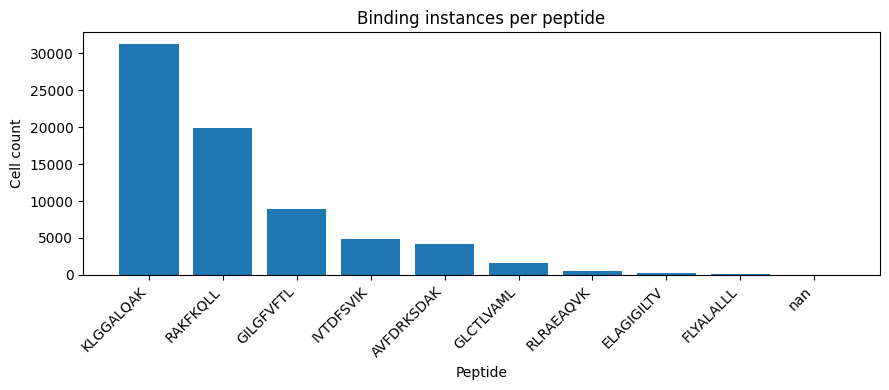

Unique peptides: 10


In [4]:
pep_counts = obs.loc[valid_tcr & valid_pep, pep_col].value_counts()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(pep_counts)), pep_counts.values)
ax.set_xticks(range(len(pep_counts)))
ax.set_xticklabels(pep_counts.index, rotation=45, ha='right')
ax.set_xlabel('Peptide')
ax.set_ylabel('Cell count')
ax.set_title('Binding instances per peptide')
plt.tight_layout()
plt.show()
print(f"Unique peptides: {len(pep_counts)}")

## 3. Generate Negative Samples

Negative TCR-peptide pairs are generated in two stages:

1. **Large pool** — for each TCR (including cells without a peptide annotation), attempt up to `k`
   unique peptide pairings drawn uniformly at random, excluding known positive pairs.
2. **Final sample** — draw `n_positives x negative_ratio` rows from the pool.

With 9 unique peptides in this dataset, `k` is automatically capped at 9 inside the tool.  
The large pool is generated once and reused across both negative ratios.

In [5]:
def generate_dataset(negative_ratio, random_seed=RANDOM_SEED):
    ratio_tag = f"neg_ratio_{int(negative_ratio)}_1"
    data_dir  = Path(f"data/{ratio_tag}")
    data_dir.mkdir(parents=True, exist_ok=True)
    (data_dir / "split_indices").mkdir(exist_ok=True)

    sampler = NegativeSamplingTool(
        data_dir="data",
        negative_ratio=negative_ratio,
        random_seed=random_seed,
        shared_negative_dir="output/negative_samples",
    )

    result = sampler.create_combined_dataset(
        negative_ratio=negative_ratio,
        k_multiplier=9,
    )

    combined = result['dataset']

    out_csv = data_dir / "combined_tcr_peptide_dataset.csv"
    combined.to_csv(out_csv, index=False)
    print(f"Saved: {out_csv}  ({len(combined):,} rows)")
    return combined, data_dir


datasets = {}
for ratio in NEGATIVE_RATIOS:
    print(f"\n{'='*50}  Ratio {int(ratio)}:1")
    combined, data_dir = generate_dataset(ratio)
    datasets[ratio] = (combined, data_dir)


==================================================  Ratio 3:1
Negative Sampling Tool initialized
   Data directory: data
   Experiment: neg_ratio_3_1
   Negative ratio: 3.0
   Output directory: output/experiments/neg_ratio_3_1/processed_data
   Indices directory: output/experiments/neg_ratio_3_1/sample_indices
   Shared negative directory: output/negative_samples
   Random seed: 42

 CREATING COMBINED DATASET (10x Only)

 Loading dataset...
    10X dataset loaded: (145479, 5000)

 Auto-detecting columns for 10X...
    TCR column: cdr3_TRB
    Peptide column: peptide

 Extracting positive pairs from 10X...
    Original dataset size: 145479 samples
    Found donor information
    Before filtering: 145479 samples
    Unique TCRs before filtering: 52470
    Unique Peptides before filtering: 10
    After filtering: 71841 valid pairs
    Unique TCRs: 14966
    Unique Peptides: 9
    tcr_source_index range: 0-145478
    peptide_source_index range: 0-145478

 Extracting positive pairs from 10

## 4. Dataset Statistics

In [6]:
for ratio, (combined, _) in datasets.items():
    n_pos = (combined['label'] == 1).sum()
    n_neg = (combined['label'] == 0).sum()
    print(f"--- {int(ratio)}:1 ---")
    print(f"  Total : {len(combined):,}  |  Pos: {n_pos:,}  Neg: {n_neg:,}  Ratio: {n_neg/n_pos:.2f}")
    print(f"  Unique TCRs: {combined['tcr'].nunique():,}  |  Unique peptides: {combined['peptide'].nunique():,}")
    print()

--- 3:1 ---
  Total : 287,364  |  Pos: 71,841  Neg: 215,523  Ratio: 3.00
  Unique TCRs: 49,353  |  Unique peptides: 9

--- 5:1 ---
  Total : 431,046  |  Pos: 71,841  Neg: 359,205  Ratio: 5.00
  Unique TCRs: 52,158  |  Unique peptides: 9



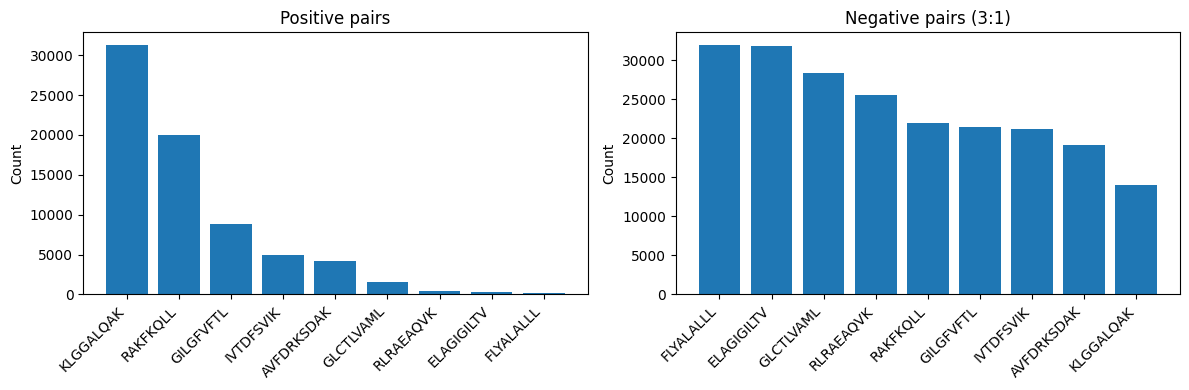

In [7]:
combined_3, _ = datasets[3.0]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, lv, title in zip(axes, [1, 0], ['Positive pairs', 'Negative pairs (3:1)']):
    counts = combined_3[combined_3['label'] == lv]['peptide'].value_counts()
    ax.bar(range(len(counts)), counts.values)
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=45, ha='right')
    ax.set_title(title)
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 5. Train/Val/Test Splits

Three splitting strategies, each with 5 independent runs:

| Strategy | Used in | Description |
|---|---|---|
| `random_split` | both notebooks | Stratified random — TCRs may appear in multiple partitions |
| `tcr_split` | beta notebook | GroupShuffleSplit by CDR3b — no beta sequence in both train/val and test |
| `tcr_ab_split` | alpha-beta notebook | GroupShuffleSplit by paired (CDR3a, CDR3b) — no paired chain combination spans train/val and test |

`random_split` indices are shared: the same files are used by both the beta-only and alpha-beta notebooks.  
`tcr_ab_split` requires alpha chain from the h5ad and is only used by `tcr_alpha_beta_prediction_notebook.ipynb`.

In [8]:
# Build alpha-chain lookup from the h5ad for tcr_ab_split
# Maps tcr_source_index -> CDR3a sequence
alpha_lookup = (
    obs[['cdr3_TRA']]
    .reset_index(drop=True)          # row position = tcr_source_index
    .rename(columns={'cdr3_TRA': 'tcr_alpha'})
    .assign(tcr_source_index=lambda df: df.index)
) if 'cdr3_TRA' in obs.columns else None

if alpha_lookup is not None:
    n_with_alpha = alpha_lookup['tcr_alpha'].notna().sum()
    print(f"Cells with CDR3a in h5ad: {n_with_alpha:,} / {len(alpha_lookup):,}")
else:
    print("No cdr3_TRA column found — tcr_ab_split will not be generated")

Cells with CDR3a in h5ad: 145,479 / 145,479


In [9]:
def save_split(train_idx, val_idx, test_idx, split_type, run, data_dir):
    idx_dir = Path(data_dir) / "split_indices"
    np.save(idx_dir / f"train_indices_{split_type}_{run}.npy", train_idx)
    np.save(idx_dir / f"val_indices_{split_type}_{run}.npy",   val_idx)
    np.save(idx_dir / f"test_indices_{split_type}_{run}.npy",  test_idx)


def make_random_split(data, run, test_size=0.15, val_size=0.15):
    idx    = np.arange(len(data))
    labels = data['label'].values
    tv, te = train_test_split(idx, test_size=test_size, stratify=labels, random_state=run)
    tr, va = train_test_split(tv, test_size=val_size/(1-test_size),
                               stratify=labels[tv], random_state=run)
    return tr, va, te


def make_tcr_split(data, run, test_size=0.20, val_size=0.15):
    """GroupShuffleSplit by CDR3b — no beta chain overlap between train/val and test."""
    idx  = np.arange(len(data))
    tcrs = data['tcr'].values
    gss  = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=run)
    tv_pos, te_pos = next(gss.split(idx, groups=tcrs))
    tv, te = idx[tv_pos], idx[te_pos]
    tr, va = train_test_split(tv, test_size=val_size/(1-test_size),
                               stratify=data['label'].values[tv], random_state=run)
    return tr, va, te


def make_tcr_ab_split(data, alpha_lookup, run, test_size=0.20, val_size=0.15):
    """GroupShuffleSplit by paired (CDR3a, CDR3b) — no paired chain combination
    spans train/val and test. Rows without CDR3a fall back to CDR3b as the group key."""
    # Join alpha chain by tcr_source_index
    merged = data.merge(
        alpha_lookup[['tcr_source_index', 'tcr_alpha']],
        on='tcr_source_index', how='left'
    )
    # Paired group key: 'CDR3a_CDR3b'; fall back to CDR3b alone if alpha is missing
    ab_groups = (merged['tcr_alpha'].astype(str).replace('nan', '') + '_' + merged['tcr']).values

    idx = np.arange(len(data))
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=run)
    tv_pos, te_pos = next(gss.split(idx, groups=ab_groups))
    tv, te = idx[tv_pos], idx[te_pos]
    tr, va = train_test_split(tv, test_size=val_size/(1-test_size),
                               stratify=data['label'].values[tv], random_state=run)
    return tr, va, te

In [10]:
for ratio, (combined, data_dir) in datasets.items():
    print(f"\nGenerating splits for {int(ratio)}:1 ...")
    for run in range(1, N_RUNS + 1):
        # random_split — used by both beta and alpha-beta notebooks
        tr, va, te = make_random_split(combined, run=run)
        save_split(tr, va, te, 'random_split', run, data_dir)

        # tcr_split — used by tcr_beta_prediction_notebook
        tr, va, te = make_tcr_split(combined, run=run)
        save_split(tr, va, te, 'tcr_split', run, data_dir)

        # tcr_ab_split — used by tcr_alpha_beta_prediction_notebook
        if alpha_lookup is not None:
            tr, va, te = make_tcr_ab_split(combined, alpha_lookup, run=run)
            save_split(tr, va, te, 'tcr_ab_split', run, data_dir)

    n_splits = N_RUNS * (3 if alpha_lookup is not None else 2)
    print(f"  {n_splits} split sets saved to: {data_dir / 'split_indices'}")


Generating splits for 3:1 ...
  15 split sets saved to: data/neg_ratio_3_1/split_indices

Generating splits for 5:1 ...
  15 split sets saved to: data/neg_ratio_5_1/split_indices


In [11]:
# Verification
combined_3, _ = datasets[3.0]

# tcr_split: no CDR3b overlap
tr, va, te = make_tcr_split(combined_3, run=1)
overlap_tcr = (set(combined_3.iloc[tr]['tcr']) | set(combined_3.iloc[va]['tcr'])) & set(combined_3.iloc[te]['tcr'])
print(f"tcr_split run 1  — (train+val) intersect test CDR3b: {len(overlap_tcr)}  (should be 0)")

# tcr_ab_split: no paired (alpha, beta) overlap
if alpha_lookup is not None:
    tr, va, te = make_tcr_ab_split(combined_3, alpha_lookup, run=1)

    def ab_pairs(subset):
        m = subset.merge(alpha_lookup[['tcr_source_index','tcr_alpha']], on='tcr_source_index', how='left')
        return set((m['tcr_alpha'].astype(str).replace('nan', '') + '_' + m['tcr']).values)

    pairs_tr = ab_pairs(combined_3.iloc[tr])
    pairs_va = ab_pairs(combined_3.iloc[va])
    pairs_te = ab_pairs(combined_3.iloc[te])
    overlap_ab = (pairs_tr | pairs_va) & pairs_te
    print(f"tcr_ab_split run 1 — (train+val) intersect test (a,b) pairs: {len(overlap_ab)}  (should be 0)")

tcr_split run 1  — (train+val) intersect test CDR3b: 0  (should be 0)
tcr_ab_split run 1 — (train+val) intersect test (a,b) pairs: 0  (should be 0)
